Robert Armenta,
Mauricio Ferreyra-Ruiz

https://www.kaggle.com/datasets/anooper/admission-predict


In [ ]:
import numpy as np                          # For numerical operations
import pandas as pd                         # For loading and managing the dataset
import matplotlib.pyplot as plt             # For plotting the PCA scatter chart

from sklearn.preprocessing import StandardScaler   # For normalizing feature values
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder             # For reducing dimensions via PCA

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:

from google.colab import files   # Code to be able to upload files from google colab
uploaded = files.upload()    # A dialog will pop up to choose your file
print('File uploaded!')

# Load the CSV file into a Pandas DataFrame
# A DataFrame is like a spreadsheet — rows are samples, columns are features
AP = pd.read_csv('Admission_Predict_Ver1.1.csv')

# Confirm the data loaded correctly by checking its shape (rows, columns)
print('Dataset shape:', AP.shape)   # Expected: (178, 14)

# Preview the first 5 rows to understand the data structure
AP.head()


Saving Admission_Predict_Ver1.1.csv to Admission_Predict_Ver1.1 (1).csv
File uploaded!
Dataset shape: (500, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
AP.dropna() #Featured Engineering dropping null columns

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [ ]:
AP.drop("GRE Score", axis=1, inplace=True) # Featured Engineering dropping GRE Score column
AP.drop("TOEFL Score", axis=1, inplace=True) # Featured Engineering dropping TOEFL Score column


In [ ]:
# Automatically identify all feature columns (everything except the label column)
# This approach is flexible — it works even if columns are reordered
features = [col for col in AP.columns if col != 'University Rating']

print('Number of features:', len(features))   # Expected: 13
print('Feature names:', features)

print()

# Check how many samples belong to each cultivar (class balance)
# Imbalanced classes can sometimes affect how well PCA separates groups visually
print('Label distribution (Serial No.):')
print(AP['University Rating'].value_counts().sort_index())
# Cultivar 1: 59 samples | Cultivar 2: 71 samples | Cultivar 3: 48 samples


Number of features: 6
Feature names: ['Serial No.', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit ']

Label distribution (Serial No.):
University Rating
1     34
2    126
3    162
4    105
5     73
Name: count, dtype: int64


In [ ]:
# Extract only the feature columns (exclude the label 'Wine_type')
# wine_dataset[features] gives us a 178 x 13 table of raw measurements
numerical_value = AP[features]
# Apply StandardScaler:
#   fit_transform() = learn the mean & std from the data, then apply the transformation
# Result: x is a 178 x 13 NumPy array with each feature having mean=0 and std=1
x = StandardScaler().fit_transform(numerical_value)

# Verify normalization worked correctly
# Mean should be extremely close to 0, Std should be exactly 1.0
print('Normalized data stats:')
print('  Mean : {:.6f}  (should be ~0)'.format(np.mean(x)))
print('  Std  : {:.6f}  (should be ~1)'.format(np.std(x)))
print('  Shape:', x.shape)   # Should be (178, 13)

Normalized data stats:
  Mean : 0.000000  (should be ~0)
  Std  : 1.000000  (should be ~1)
  Shape: (500, 6)


In [ ]:
# Initialize PCA and reduce from 13 dimensions → 2 principal components
# n_components=2 means we keep only the 2 most informative directions
pca = PCA(n_components=2)

# fit_transform() does two things:
#   fit()      = learns the principal component directions from the data
#   transform()= projects all 178 samples onto those 2 new axes
# Result: a 178 x 2 array — each sample now has just 2 coordinates (PC1, PC2)
principal_components = pca.fit_transform(x)

print('PCA output shape:', principal_components.shape)  # Expected: (178, 2)

# Wrap the PCA output in a DataFrame for easy indexing and plotting
# Each row is one wine sample; columns are its position on PC1 and PC2
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])

print()
print('First 5 rows of PCA result:')
print(pca_df.head())

PCA output shape: (500, 2)

First 5 rows of PCA result:
        PC1       PC2
0  2.934655 -1.583505
1  1.511968 -1.596370
2 -0.261055 -1.518744
3  0.325982 -1.594369
4 -1.731624 -1.674235


In [ ]:
# explained_variance_ratio_ gives the proportion of variance captured by each component
# Index [0] = PC1, Index [1] = PC2
pc1_var, pc2_var = pca.explained_variance_ratio_

print('Explained variance per principal component:')
print('  PC1 : {:.1%}  — direction of greatest spread in the data'.format(pc1_var))
print('  PC2 : {:.1%}  — direction of second greatest spread'.format(pc2_var))
print('  ──────────────────────────────────────────────')
print('  Total: {:.1%}  of original information retained in 2D'.format(pc1_var + pc2_var))

Explained variance per principal component:
  PC1 : 57.8%  — direction of greatest spread in the data
  PC2 : 17.0%  — direction of second greatest spread
  ──────────────────────────────────────────────
  Total: 74.7%  of original information retained in 2D


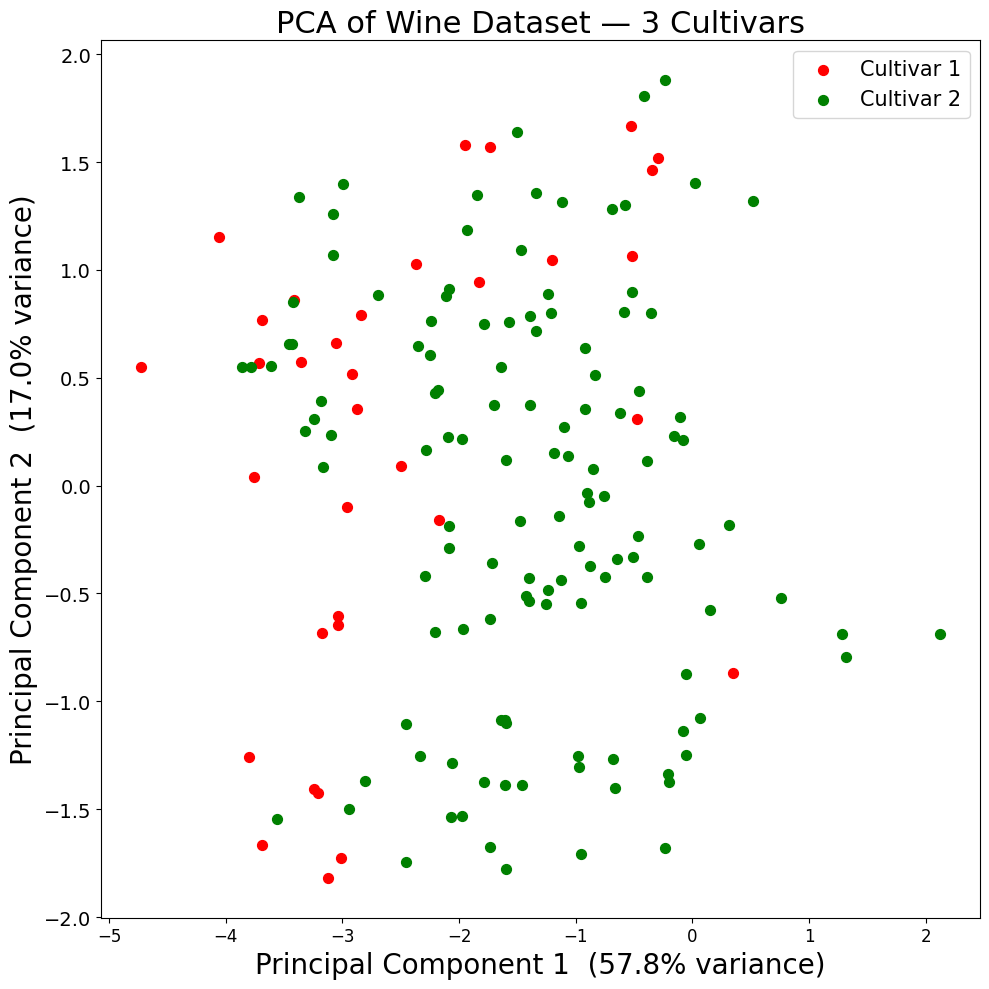

Plot saved as pca_wine.png


In [ ]:
 #Set up the figure canvas (50x50 inches for a clear, large plot)
plt.figure(figsize=(10, 10))

# Axis labels and title
plt.xlabel('Principal Component 1  ({:.1%} variance)'.format(pc1_var), fontsize=20)
plt.ylabel('Principal Component 2  ({:.1%} variance)'.format(pc2_var), fontsize=20)
plt.title('PCA of Wine Dataset — 3 Cultivars', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

# Define one color and display name per cultivar
# Dictionary format: {label: (color_code, legend_name)}
colors = {
    1: ('r', 'Cultivar 1'),   # Red   — 59 samples
    2: ('g', 'Cultivar 2'),   # Green — 71 samples
      # Blue  — 48 samples
}

# Loop through each cultivar and plot its points separately
# This allows each group to have its own color in the legend
for label, (color, name) in colors.items():

    # Create a boolean mask: True for rows where Wine_type matches the current label
    mask = AP['University Rating'] == label

    # Plot only the PC1/PC2 values for this cultivar's samples
    plt.scatter(
        pca_df.loc[mask, 'PC1'],   # x-axis: position along PC1
        pca_df.loc[mask, 'PC2'],   # y-axis: position along PC2
        c=color,                   # dot color
        s=50,                      # dot size
        label=name                 # legend entry
    )

# Add legend, tighten layout, and display
plt.legend(prop={'size': 15})
plt.tight_layout()
plt.savefig('pca_wine.png', dpi=150)   # Save a high-resolution copy
plt.show()

print('Plot saved as pca_wine.png')

# **Executive Summary of Admission Predictions**

In this dataset we decided to run the algorithm of Principal Component Analysis. The purpose of using this algorithm was to reduce the amount of dimensions that were in the dataset as well as improve the efficiency of the results being provided. This whole dataset consisted of 500 observations with 7 different variables. These variables consisted of GRE Score, TOEFL Score, University rating, Statement of Purpose, Letters of Reccomendations, CGPA, and Research Experience. All of these variables contribute to different Academic Performance Indicators that are closely correlated together.

In order to reduce the issue of redudancy within different data sets the algorithm Principal Component Analysis was created. With this algorithm you are able to retain the most important variables and reducing the amount of redudancy that can negatively impact the analysis.

After performing the Principal Component Analysis we found out that the first component accounted for approximately 67.5% of the total variance in the dataset. When you combine this with the second component, approximately 78% of the total variance gets retained. Moving on with the third component we notice another increase of the total explained variance to about 86%. These findings help shed light that the majority of the informational value within the 7 variables can be represented accurately using a lower amount of dimensions.